C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


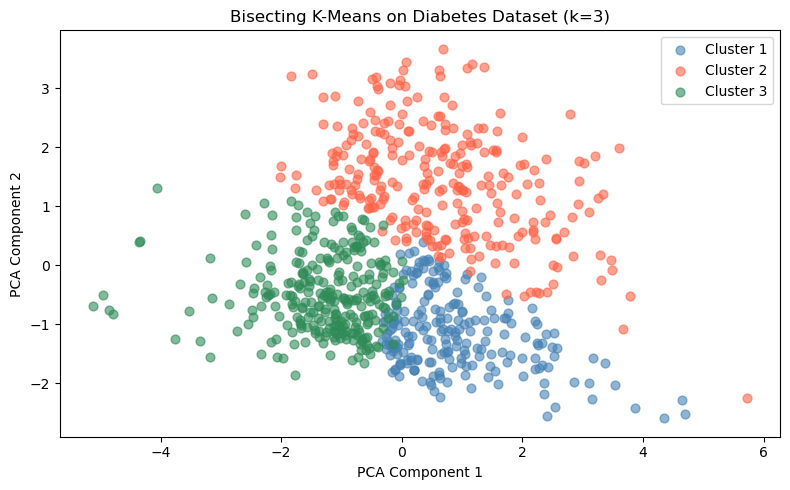

Cluster 1: 220 points
Cluster 2: 272 points
Cluster 3: 276 points


In [2]:

import os
os.environ["OMP_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load and preprocess data
df = pd.read_csv('diabetes_dataset.csv')
X = df.drop('Outcome', axis=1)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Bisecting K-Means implementation
def bisecting_kmeans(X, k):
    clusters = [X]          # start with all points in one cluster
    labels = np.zeros(len(X), dtype=int)

    while len(clusters) < k:
        # Pick largest cluster to split
        largest_idx = np.argmax([len(c) for c in clusters])
        cluster_to_split = clusters.pop(largest_idx)

        # Get original indices of points in this cluster
        mask = labels == largest_idx
        original_indices = np.where(mask)[0]

        # Bisect using KMeans with k=2
        km = KMeans(n_clusters=2, n_init=5, random_state=42)
        sub_labels = km.fit_predict(cluster_to_split)

        # Split into two sub-clusters
        c1 = cluster_to_split[sub_labels == 0]
        c2 = cluster_to_split[sub_labels == 1]
        clusters.insert(largest_idx, c1)
        clusters.append(c2)

        # Update global labels
        new_label = len(clusters) - 1
        labels[original_indices[sub_labels == 1]] = new_label

    return labels, clusters

# Run Bisecting K-Means for k=3
k = 3
labels, clusters = bisecting_kmeans(X_scaled, k)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8, 5))
colors = ['steelblue', 'tomato', 'seagreen']
for i in range(k):
    mask = labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i+1}', alpha=0.6, s=40)

plt.title('Bisecting K-Means on Diabetes Dataset (k=3)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('bisecting_kmeans.png', dpi=150)
plt.show()

# Print cluster sizes
for i, c in enumerate(clusters):
    print(f"Cluster {i+1}: {len(c)} points")